# WikiArt Painter Classification — Training Notebook (Colab)

**Deep Learning — Course Project**

This notebook trains models on the **pre-cleaned, pre-split** `wikiart_split` dataset.

## Strategy
1. **Phase 1 — Feature Extraction**: Freeze the entire EfficientNetB0 backbone, train only the new classification head.
2. **Phase 2 — Fine-tuning**: Unfreeze the top layers of the backbone, train end-to-end at a lower learning rate.

---
## 0. Setup & Data Loading

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers
from tensorflow.keras.applications import ResNet50, EfficientNetB0, ConvNeXtTiny
from tensorflow.keras.layers import LeakyReLU

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import cv2

import zipfile

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
# ── Unzip config ─────────────────────────────────────────────────────────────
ZIP_PATH   = Path('/content/drive/MyDrive/wikiart_split.zip')  # ajusta se necessário
EXTRACT_TO = Path('/content/wikiart_split')                     # disco local do Colab

if not EXTRACT_TO.exists():
    print('A extrair ZIP... (pode demorar 1-2 min na primeira vez)')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_TO.parent)
    print('Extração concluída!')
else:
    print('Pasta já existe, a saltar extração.')

A extrair ZIP... (pode demorar 1-2 min na primeira vez)
Extração concluída!


In [5]:
# ── Config ──────────────────────────────────────────────────────────────────
# TODO: adjust this path to where wikiart_split is stored in your Drive
SPLIT_DIR   = EXTRACT_TO

IMG_SIZE    = (224, 224)   # EfficientNetB0 default also ResNet50
BATCH_SIZE  = 32
NUM_CLASSES = 23
AUTOTUNE    = tf.data.AUTOTUNE

train_dir = SPLIT_DIR / 'train'
val_dir   = SPLIT_DIR / 'val'
test_dir  = SPLIT_DIR / 'test'

# Training hyperparameters
PHASE1_EPOCHS    = 30
PHASE1_LR        = 1e-3
PHASE2_EPOCHS    = 50
PHASE2_LR        = 1e-4
FINE_TUNE_LAYERS = 30      # number of backbone layers to unfreeze in Phase 2

# Callback settings
ES_PATIENCE_P1   = 7       # EarlyStopping patience (Phase 1)
ES_PATIENCE_P2   = 10      # EarlyStopping patience (Phase 2)
LR_FACTOR        = 0.5     # ReduceLROnPlateau decay factor
LR_PATIENCE_P1   = 3       # ReduceLROnPlateau patience (Phase 1)
LR_PATIENCE_P2   = 4       # ReduceLROnPlateau patience (Phase 2)
LR_MIN_P1        = 1e-6
LR_MIN_P2        = 1e-7

# TTA
TTA_STEPS        = 10
COMPARE_EPOCHS   = 15      # backbone comparison (Phase 1 only)

print('Keras  :', keras.__version__)
print('TF     :', tf.__version__)
print('GPU    :', tf.config.list_physical_devices('GPU') or 'None - CPU mode')
print('Split  :', SPLIT_DIR)
print('Exists :', SPLIT_DIR.exists())

Keras  : 3.13.2
TF     : 2.19.0
GPU    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Split  : /content/wikiart_split
Exists : True


---
## 1. tf.data Pipeline

Não corri com augmentations para já, mas random erasing pareceu me interessante e ajuda bastante com overfit supostamente

In [ ]:
# ── Augmentation pipeline (training only) ──────────────────────────────────
"""color_spatial_aug = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.15),
    layers.RandomHue(factor=0.05),
    layers.RandomSaturation(factor=(0.7, 1.3)),
], name='color_spatial_aug')

random_erasing = layers.RandomErasing(
    scale=(0.02, 0.15),
    ratio=(0.3, 3.3),
    fill_mode='constant',
    fill_value=0.0,
    name='random_erasing'
)"""

In [6]:
# ── Load datasets from pre-split folders ──────────────────────────────────
train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    verbose=False
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

class_names = train_ds_raw.class_names
print(f'Classes ({len(class_names)}): {class_names}')

Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [ ]:
# ── Apply augmentation + ResNet preprocessing ───────────────────────
def apply_augmentation(img, label):
    #img = color_spatial_aug(img, training=True)
    #img = tf.clip_by_value(img, 0.0, 255.0)
    img = keras.applications.resnet50.preprocess_input(img)
    #img = random_erasing(img, training=True)
    return img, label

def apply_preprocessing(img, label):
    img = keras.applications.resnet50.preprocess_input(img)
    return img, label

train_ds = (
    train_ds_raw
    .shuffle(buffer_size=1000, seed=SEED)
    .map(apply_augmentation, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(apply_preprocessing, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds_raw
    .map(apply_preprocessing, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print(f'Train batches: {len(train_ds)}')
print(f'Val batches  : {len(val_ds)}')
print(f'Test batches : {len(test_ds)}')

Train batches: 313
Val batches  : 63
Test batches : 42


Também não adicionei class weights para os testes iniciais

In [ ]:
# Class weights to handle imbalance during training
"""train_labels_flat = np.concatenate([
    np.argmax(y.numpy(), axis=1) for _, y in train_ds_raw
])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels_flat
)
class_weight_dict = dict(enumerate(class_weights_array))

print('Class weights (top 5 heaviest):')
sorted_cw = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)
for idx, w in sorted_cw[:5]:
    print(f'  {class_names[idx]:<30} -> {w:.3f}')"""

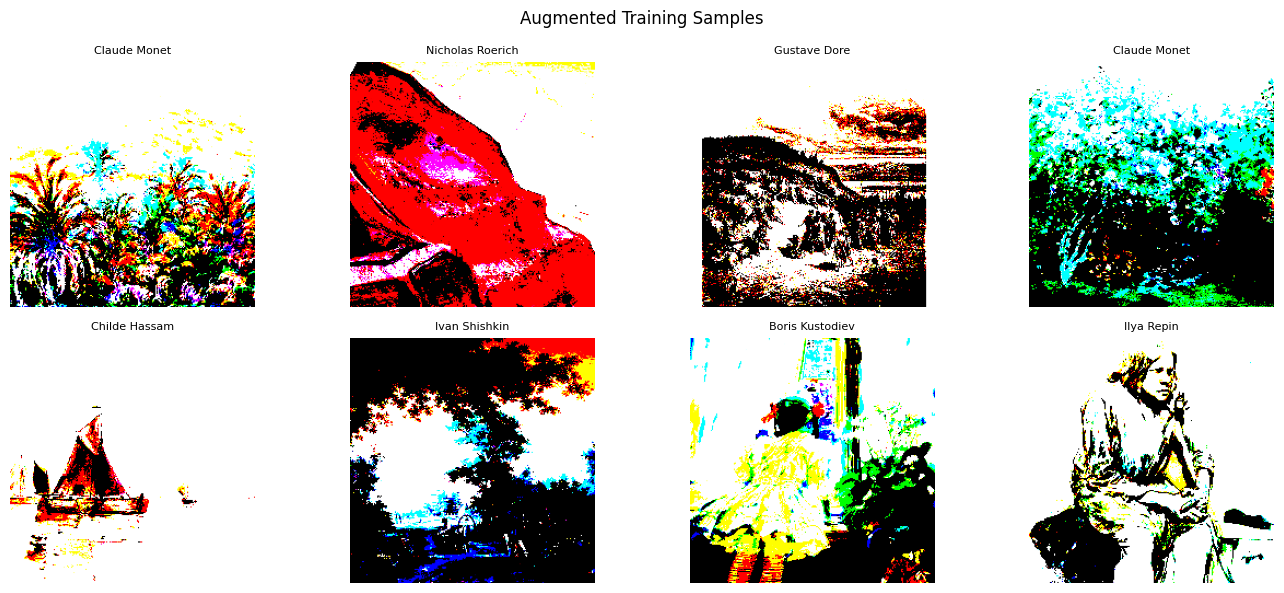

In [ ]:
# Visualise a batch of augmented training samples
sample_imgs, sample_labels = next(iter(train_ds))
sample_display = np.clip((sample_imgs[:8].numpy() + 1.0) / 2.0, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, img, lbl in zip(axes.flatten(), sample_display, sample_labels[:8]):
    ax.imshow(img)
    ax.set_title(class_names[np.argmax(lbl)].replace('_', ' '), fontsize=8)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. Model Architecture

```
Input (224x224x3)
  -> EfficientNetB0 backbone (pretrained, frozen in Phase 1)
       -> GlobalAveragePooling2D
            -> BatchNormalization
                 -> Dense(512, relu) + Dropout(0.4)
                      -> Dense(256, relu) + Dropout(0.3)
                           -> Dense(23, softmax)
```

In [ ]:
def build_model(freeze_base=True):
    """Build ResNet50 transfer learning model."""

    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3)
    )
    base_model.trainable = not freeze_base

    inputs  = keras.Input(shape=(*IMG_SIZE, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(freeze_base=True) # freeze the model, only the last Dense layer will learn during training

total_params = model.count_params()
trainable_p1 = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Total parameters   : {total_params:,}')
print(f'Trainable (Phase 1): {trainable_p1:,}')
model.summary(expand_nested=False)

Total parameters   : 23,634,839
Trainable (Phase 1): 47,127


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │        47,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,634,839 (90.16 MB)

 Trainable params: 47,127 (184.09 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

---
## 5. Architecture Comparison

To validate our choice of EfficientNetB0 and understand how architecture affects performance on artistic style classification, we compare **four backbones** using the same training pipeline (Phase 1 only — frozen backbone, identical head and hyperparameters).

| Backbone | Why include it? |
|---|---|
| **EfficientNetB0** | Our primary model — compound-scaled CNN, strong accuracy/size ratio |
| **VGG16** | Classic deep CNN — large but historically strong on texture/style tasks |
| **ResNet50V2** | Residual connections baseline — widely used reference point |
| **ConvNeXt-Tiny** | Modern pure-CNN (2022) — incorporates Transformer design ideas into a CNN, often outperforms EfficientNets |

All models use ImageNet pretrained weights. We train only the classification head (frozen backbone) for a fixed number of epochs to ensure a fair comparison. The best `val_macro_f1` from each run is recorded.

---
## 3. Phase 1 — Feature Extraction (frozen backbone)

In [7]:
def make_metrics():
    return [
        keras.metrics.F1Score(
            average='macro',
            name='macro_f1'
        ),
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy'), # O pintor correto estava nas 3 primeiras sugestões ?
        keras.metrics.AUC(
            multi_label=True,
            num_labels=NUM_CLASSES,
            name='auc'
        ),
    ]

In [8]:
# Compare backbones using the same head, data pipeline, and training schedule.
# Only Phase 1 (frozen backbone) is used for a fair, fast comparison.

import gc
from keras.applications import VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3

# ConvNeXtTiny normalises internally — pass identity function
def _identity(x):
    return x

BACKBONE_CONFIGS = {
    'EfficientNetB0': {
        'model_fn': EfficientNetB0,
        'preprocess': keras.applications.efficientnet.preprocess_input,
    },
    'EfficientNetB3': {
        'model_fn': EfficientNetB3,
        'preprocess': keras.applications.efficientnet.preprocess_input,
    },
    'VGG16': {
        'model_fn': VGG16,
        'preprocess': keras.applications.vgg16.preprocess_input,
    },
    'ResNet50V2': {
        'model_fn': ResNet50V2,
        'preprocess': keras.applications.resnet_v2.preprocess_input,
    },
    'ConvNeXtTiny': {
        'model_fn': ConvNeXtTiny,
        'preprocess': keras.applications.convnext.preprocess_input,
    },
}

In [9]:
def make_pipeline_no_aug(preprocess_fn):
    """
    Clean pipeline — no augmentations.
    Measures raw backbone feature extraction capacity.
    """
    def pre(img, label):
        return preprocess_fn(img), label

    t_ds = (train_ds_raw
            .shuffle(1000, seed=SEED)
            .map(pre, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
    v_ds = (val_ds_raw
            .map(pre, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
    return t_ds, v_ds

In [ ]:
def build_comparison_model(backbone_fn):
    """Build a model with the given backbone (frozen) and standard head."""
    bb = backbone_fn(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3)
    )
    bb.trainable = False

    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x   = bb(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(256, activation='relu')(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out), bb





# ── Comparison loop ─────────────────────────────────────────────────────────
comparison_results = {}

for name, cfg in BACKBONE_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'  Training {name}')
    print(f'{"="*60}')

    comp_model, comp_bb = build_comparison_model(cfg['model_fn'])
    comp_train, comp_val = make_pipeline_no_aug(cfg['preprocess'])

    n_params   = comp_model.count_params()
    trainable  = sum(tf.size(w).numpy() for w in comp_model.trainable_weights)
    print(f'  Parameters : {n_params:,} total | {trainable:,} trainable')

    comp_model.compile(
        optimizer=optimizers.Adam(learning_rate=PHASE1_LR),
        loss='categorical_crossentropy',
        metrics=make_metrics()
    )

    hist = comp_model.fit(
        comp_train,
        epochs=COMPARE_EPOCHS,          # 20-25
        validation_data=comp_val,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss',
                patience=ES_PATIENCE_P1,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=LR_FACTOR,
                patience=LR_PATIENCE_P1,
                min_lr=LR_MIN_P1,
                verbose=1
            ),
        ],
        verbose=1
    )

    comparison_results[name] = {
        'params':       n_params,
        'trainable':    trainable,
        'best_val_f1':  max(hist.history['val_macro_f1']),
        'best_val_top3': max(hist.history['val_top3_accuracy']),
        'min_val_loss': min(hist.history['val_loss']),
        'history':      hist.history,
    }

    print(f'  Best val macro F1 : {comparison_results[name]["best_val_f1"]:.4f}')
    print(f'  Best val top-3    : {comparison_results[name]["best_val_top3"]:.4f}')
    print(f'  Min val loss      : {comparison_results[name]["min_val_loss"]:.4f}')

    # ── Libertar memória GPU antes do próximo backbone ──
    del comp_model, comp_bb
    keras.backend.clear_session()
    gc.collect()

In [ ]:
# ── Comparison Results — Visualisation & Summary ────────────────────────────

# Summary table (sorted by F1, with trainable params)
print(f'{"Backbone":<20} {"Total Params":>13} {"Trainable":>11} {"Val Macro F1":>14} {"Val Top-3":>12} {"Val Loss":>10}')
print('-' * 82)
for name, r in sorted(comparison_results.items(),
                       key=lambda x: x[1]['best_val_f1'], reverse=True):
    print(f'{name:<20} {r["params"]:>13,} {r["trainable"]:>11,} '
          f'{r["best_val_f1"]:>14.4f} {r["best_val_top3"]:>12.4f} '
          f'{r["min_val_loss"]:>10.4f}')

# ── Curvas de treino: F1, Loss, Overfitting Gap ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for name, r in comparison_results.items():
    epochs = range(1, len(r['history']['val_macro_f1']) + 1)
    axes[0].plot(epochs, r['history']['val_macro_f1'], label=name, linewidth=2)
    axes[1].plot(epochs, r['history']['val_loss'],     label=name, linewidth=2)

    gap = [tr - va for tr, va in zip(r['history']['macro_f1'],
                                      r['history']['val_macro_f1'])]
    axes[2].plot(epochs, gap, label=name, linewidth=2)

axes[0].set_title('Validation Macro F1 by Backbone')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Macro F1')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss by Backbone')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Overfitting Gap (Train − Val F1)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1 Gap')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Backbone Comparison — Phase 1 Only (Frozen Backbone)', fontsize=13)
plt.tight_layout()
plt.savefig('backbone_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar chart: F1 vs Model Size (ordenado por F1) ────────────────────────────
sorted_names = sorted(comparison_results.keys(),
                      key=lambda n: comparison_results[n]['best_val_f1'],
                      reverse=True)
f1s    = [comparison_results[n]['best_val_f1'] for n in sorted_names]
params = [comparison_results[n]['params'] / 1e6 for n in sorted_names]

fig, ax1 = plt.subplots(figsize=(10, 5))
x    = range(len(sorted_names))
bars = ax1.bar(x, f1s, color='steelblue', alpha=0.8, label='Macro F1')
ax1.set_ylabel('Best Val Macro F1')
ax1.set_xticks(x)
ax1.set_xticklabels(sorted_names, rotation=15)

ax2 = ax1.twinx()
ax2.plot(x, params, 'ro-', label='Params (M)', linewidth=2)
ax2.set_ylabel('Parameters (millions)')

ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
ax1.grid(alpha=0.3, axis='y')
plt.title('Performance vs Model Size')
plt.tight_layout()
plt.savefig('backbone_f1_vs_params.png', dpi=150, bbox_inches='tight')
plt.show()

### Backbone Comparison — Analysis

*(Fill in after running the comparison)*

| Backbone | Params | Best Val Macro F1 | Best Val Top-3 | Notes |
|---|---|---|---|---|
| EfficientNetB0 | 5.3M | 0.6448 | 0.8591 | Baseline |
| VGG16 | 138M | 0.6329 | 0.8536 | Classic, large |
| ResNet50V2 | 25.6M | 0.6284| 0.8521 | Residual baseline |
| ConvNeXt-Tiny | 28.6M | 0.7100 |0.8946 | Modern CNN |

**Key observations:**
- (Which backbone performed best? Was it the largest?)
- (Did any backbone converge faster?)
- (Does model size correlate with performance for this dataset?)
- (Justification for keeping EfficientNetB0 as the primary model, or switching)

---
### 5b. Optimizer Comparison

Having identified the best backbone, we now isolate **the optimizer** as the single variable.
All runs use EfficientNetB0 (frozen), the same classification head, and Phase 1 settings.

| Optimizer | Why include it? |
|---|---|
| **Adam** | Our baseline — adaptive learning rates, fast convergence, most popular default |
| **AdamW** | Adam with *decoupled* weight decay — often generalises better than vanilla Adam on image tasks |
| **SGD + Momentum** | Classic optimizer — slower to converge but sometimes reaches a flatter (more generalisable) minimum |

By comparing these three we can determine whether the default Adam is truly optimal,
or whether a different optimisation strategy better suits artistic style classification.

In [ ]:
# ── Optimizer Comparison ─────────────────────────────────────────────────
# Same backbone (EfficientNetB0), same head, same data pipeline.
# Only the optimizer changes.

# ── Optimizer Comparison ─────────────────────────────────────────────────────
# Fixed backbone: ConvNeXtTiny (frozen), same head, same data pipeline.
# Only the optimizer changes. No augmentations — isolates optimizer as variable.

LION_LR = PHASE1_LR / 5   # Lion uses LR 3-10x lower than Adam

OPTIMIZER_CONFIGS = {
    'Adam':     lambda: optimizers.Adam(learning_rate=PHASE1_LR),
    'AdamW':    lambda: optimizers.AdamW(learning_rate=PHASE1_LR, weight_decay=1e-4),
    'Lion':     lambda: optimizers.Lion(learning_rate=LION_LR, weight_decay=1e-4),
    'RMSprop':  lambda: optimizers.RMSprop(learning_rate=PHASE1_LR, rho=0.9),
}

optimizer_results = {}

for opt_name, opt_fn in OPTIMIZER_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'  ConvNeXtTiny + {opt_name}')
    print(f'{"="*60}')

    opt_model, opt_bb = build_comparison_model(ConvNeXtTiny)
    opt_train, opt_val = make_pipeline_no_aug(_identity)

    n_params  = opt_model.count_params()
    trainable = sum(tf.size(w).numpy() for w in opt_model.trainable_weights)
    print(f'  Parameters: {n_params:,} total | {trainable:,} trainable')

    opt_model.compile(
        optimizer=opt_fn(),
        loss='categorical_crossentropy',
        metrics=make_metrics()
    )

    hist = opt_model.fit(
        opt_train,
        epochs=COMPARE_EPOCHS,
        validation_data=opt_val,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss',
                patience=ES_PATIENCE_P1,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=LR_FACTOR,
                patience=LR_PATIENCE_P1,
                min_lr=LR_MIN_P1,
                verbose=1
            ),
        ],
        verbose=1
    )

    optimizer_results[opt_name] = {
        'best_val_f1':  max(hist.history['val_macro_f1']),
        'best_val_top3': max(hist.history['val_top3_accuracy']),
        'min_val_loss': min(hist.history['val_loss']),
        'history':      hist.history,
    }
    print(f'  Best val macro F1 : {optimizer_results[opt_name]["best_val_f1"]:.4f}')
    print(f'  Best val top-3    : {optimizer_results[opt_name]["best_val_top3"]:.4f}')
    print(f'  Min val loss      : {optimizer_results[opt_name]["min_val_loss"]:.4f}')

    # ── Libertar memória GPU ──
    del opt_model, opt_bb
    keras.backend.clear_session()
    gc.collect()

print(f'\n{"="*60}')
print('  Optimizer comparison complete')
print(f'{"="*60}')

In [ ]:
# ── Optimizer Comparison Results ────────────────────────────────────────────

print(f'{"Optimizer":<20} {"Val Macro F1":>14} {"Val Top-3":>12} {"Val Loss":>10}')
print('-' * 58)
for name, r in sorted(optimizer_results.items(),
                       key=lambda x: x[1]['best_val_f1'], reverse=True):
    print(f'{name:<20} {r["best_val_f1"]:>14.4f} '
          f'{r["best_val_top3"]:>12.4f} {r["min_val_loss"]:>10.4f}')

# ── Curvas: F1, Loss, Overfitting Gap ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for name, r in optimizer_results.items():
    epochs = range(1, len(r['history']['val_macro_f1']) + 1)
    axes[0].plot(epochs, r['history']['val_macro_f1'], label=name, linewidth=2)
    axes[1].plot(epochs, r['history']['val_loss'],     label=name, linewidth=2)

    gap = [tr - va for tr, va in zip(r['history']['macro_f1'],
                                      r['history']['val_macro_f1'])]
    axes[2].plot(epochs, gap, label=name, linewidth=2)

axes[0].set_title('Validation Macro F1 by Optimizer')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Macro F1')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss by Optimizer')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Overfitting Gap (Train − Val F1)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1 Gap')
axes[2].legend(); axes[2].grid(alpha=0.3)

### Optimizer Comparison — Analysis

*(Fill in after running the comparison)*

| Optimizer | Best Val Macro F1 | Best Val Top-3 | Notes |
|---|---|---|---|
| Adam |  |  | Baseline |
| AdamW |  |  | Decoupled weight decay |
| SGD + Momentum |  |  | Classic, slower convergence |

**Key observations:**
- (Which optimizer achieved the highest macro F1?)
- (Did SGD converge slower but reach a comparable/better final score?)
- (Did AdamW's weight decay help with generalisation on this dataset?)
- (Justification for the optimizer choice used in the main training pipeline)

---
### 5b. Activation function Comparison

Having identified the best backbone and optimizer, we now isolate **the activation functions** as the single variable.
All runs use ConvNeXTiny (frozen), the same classification head, and Phase 1 settings.

The activation function for the output layer is fixed (**softmax**) since we have a multiclass classification problem, so we will only experiment on the activation function of the previous Dense layer.

| Activation functions | Why include it? |
|---|---|
| **ReLU** | Our baseline — A simple and efficient baseline activation that works well in many settings, making it useful for comparison against more advanced functions. |
| **Gelu** | Used by default in ConvNeXt, it provides smooth, probabilistic activation which often leads to better performance in deep architectures. |
| **Swish** | A smooth, non-monotonic activation that can outperform ReLU in deeper networks, though it comes with slightly higher computational cost. |
| **Elu** | Helps keep activations closer to zero mean, which can improve convergence speed and training stability |
| **Leaky ReLU** | Mitigates the dying ReLU problem by allowing a small gradient when inputs are negative, often improving robustness. |

By comparing these 5 we can determine whether the default ReLU is truly optimal,
or whether a different activation function better suits artistic style classification.

In [13]:
ACTIVATIONS = {
    'relu':  lambda x: layers.Activation('relu')(x),
    'gelu':  lambda x: layers.Activation('gelu')(x),
    'swish': lambda x: layers.Activation('swish')(x),
    'elu':   lambda x: layers.Activation('elu')(x),
    'leaky_relu': lambda x: LeakyReLU(alpha=0.01)(x),
}

# Define backbone to use for testing
shared_bb = ConvNeXtTiny(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3)
)
shared_bb.trainable = False

def build_model_act(backbone, activation_name):
    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x   = backbone(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(256)(x)
    x   = ACTIVATIONS[activation_name](x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out)

In [14]:
activation_results = {}
act_train, act_val = make_pipeline_no_aug(keras.applications.convnext.preprocess_input)

for act_name, act_fn in ACTIVATIONS.items():
    print(f'\n{"="*60}')
    print(f'  ConvNeXtTiny + {act_name}')
    print(f'{"="*60}')

    model = build_model_act(shared_bb, act_name)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=PHASE1_LR),
        loss='categorical_crossentropy',
        metrics=make_metrics()
    )

    hist = model.fit(
        act_train,
        epochs=COMPARE_EPOCHS,
        validation_data=act_val,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss',
                patience=ES_PATIENCE_P1,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=LR_FACTOR,
                patience=LR_PATIENCE_P1,
                min_lr=LR_MIN_P1,
                verbose=1
            ),
        ],
        verbose=1
    )

    activation_results[act_name] = {
        'best_val_f1':  max(hist.history['val_macro_f1']),
        'best_val_top3': max(hist.history['val_top3_accuracy']),
        'min_val_loss': min(hist.history['val_loss']),

        'val_f1_curve': hist.history['val_macro_f1'],
        'val_loss_curve': hist.history['val_loss'],
        'train_f1_curve': hist.history['macro_f1'],
    }

    print(f'  Best F1: {activation_results[act_name]["best_val_f1"]:.4f}')

    # limpar memória
    del model, hist
    keras.backend.clear_session()
    gc.collect()

print(f'\n{"="*60}')
print('  Activation function comparison complete')
print(f'{"="*60}')


  ConvNeXtTiny + relu
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 191ms/step - auc: 0.9416 - loss: 1.2874 - macro_f1: 0.5983 - top3_accuracy: 0.8132 - val_auc: 0.9671 - val_loss: 0.9947 - val_macro_f1: 0.6728 - val_top3_accuracy: 0.8791 - learning_rate: 0.0010
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - auc: 0.9884 - loss: 0.5615 - macro_f1: 0.8178 - top3_accuracy: 0.9484 - val_auc: 0.9679 - val_loss: 0.8592 - val_macro_f1: 0.7298 - val_top3_accuracy: 0.8991 - learning_rate: 0.0010
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - auc: 0.9961 - loss: 0.3331 - macro_f1: 0.8976 - top3_accuracy: 0.9807 - val_auc: 0.9696 - val_loss: 0.8285 - val_macro_f1: 0.7488 - val_top3_accuracy: 0.9095 - learning_rate: 0.0010
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - auc: 0.9989 - loss: 0.1933 - macro_f1: 0.9464 - top3_accuracy: 0.9936 - val_auc: 0.9662 - val_loss: 0.8659 - val_macro_f1: 0.7423 - val_top3_accuracy: 0.9055 - learning_rate: 0.0010
Epoch 5/15
313/313 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 119ms/step - auc: 0.9399 - loss: 1.2911 - macro_f1: 0.6019 - top3_accuracy: 0.8116 - val_auc: 0.9655 - val_loss: 1.0157 - val_macro_f1: 0.6741 - val_top3_accuracy: 0.8746 - learning_rate: 0.0010
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - auc: 0.9880 - loss: 0.5593 - macro_f1: 0.8209 - top3_accuracy: 0.9509 - val_auc: 0.9693 - val_loss: 0.8453 - val_macro_f1: 0.7178 - val_top3_accuracy: 0.8991 - learning_rate: 0.0010
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - auc: 0.9963 - loss: 0.3336 - macro_f1: 0.8975 - top3_accuracy: 0.9790 - val_auc: 0.9689 - val_loss: 0.8452 - val_macro_f1: 0.7275 - val_top3_accuracy: 0.9025 - learning_rate: 0.0010
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - auc: 0.9990 - loss: 0.1845 - macro_f1: 0.9484 - top3_accuracy: 0.9949 - val_auc: 0.9647 - val_loss: 0.8722 - val_macro_f1: 0.7440 - val_top3_accuracy: 0.9030 - learning_rate: 0.0010
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - auc

Activation function    Val Macro F1    Val Top-3   Val Loss
----------------------------------------------------------
leaky_relu                   0.7705       0.9115     0.8452
relu                         0.7704       0.9270     0.8285
gelu                         0.7696       0.9205     0.8343
swish                        0.7637       0.9215     0.8201
elu                          0.7536       0.9185     0.8667


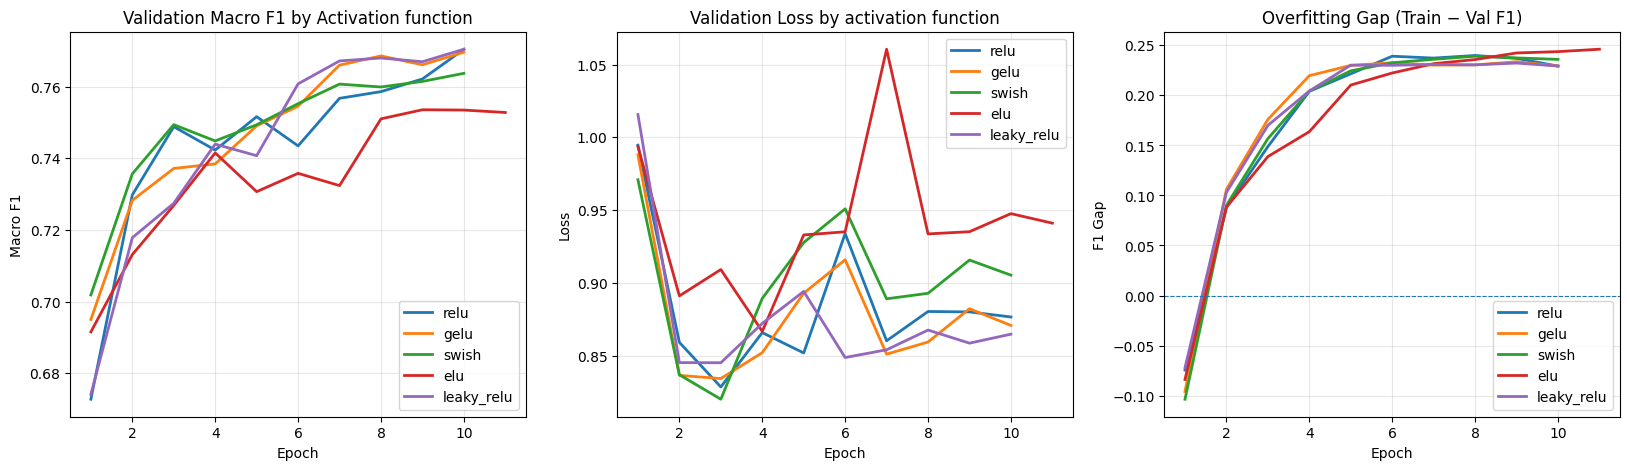

In [15]:
# ── Activation functions Comparison Results ────────────────────────────────────────────

print(f'{"Activation function":<20} {"Val Macro F1":>14} {"Val Top-3":>12} {"Val Loss":>10}')
print('-' * 58)
for name, r in sorted(activation_results.items(),
                       key=lambda x: x[1]['best_val_f1'], reverse=True):
    print(f'{name:<20} {r["best_val_f1"]:>14.4f} '
          f'{r["best_val_top3"]:>12.4f} {r["min_val_loss"]:>10.4f}')

# ── Curvas: F1, Loss, Overfitting Gap ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for name, r in activation_results.items():
    epochs = range(1, len(r['val_f1_curve']) + 1)

    axes[0].plot(epochs, r['val_f1_curve'], label=name, linewidth=2)
    axes[1].plot(epochs, r['val_loss_curve'], label=name, linewidth=2)

    gap = [tr - va for tr, va in zip(r['train_f1_curve'],
                                    r['val_f1_curve'])]
    axes[2].plot(epochs, gap, label=name, linewidth=2)

axes[0].set_title('Validation Macro F1 by Activation function')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Macro F1')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss by activation function')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].axhline(0, linestyle='--', linewidth=0.8)
axes[2].set_title('Overfitting Gap (Train − Val F1)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1 Gap')
axes[2].legend(); axes[2].grid(alpha=0.3)

### Activation functions Comparison — Analysis

*(Fill in after running the comparison)*

| Activation function | Best Val Macro F1 | Best Val Top-3 | Notes |
|---|---|---|---|
| Adam |  |  | Baseline |
| AdamW |  |  | Decoupled weight decay |
| SGD + Momentum |  |  | Classic, slower convergence |

**Key observations:**
- (Which optimizer achieved the highest macro F1?)
- (Did SGD converge slower but reach a comparable/better final score?)
- (Did AdamW's weight decay help with generalisation on this dataset?)
- (Justification for the optimizer choice used in the main training pipeline)

---
## 4. Phase 2 — Fine-tuning (unfreeze top layers)

Unfreeze the **top 30 layers** of EfficientNetB0 and train at **10x smaller learning rate** (1e-4).

In [ ]:
# Load best Phase-1 weights, then unfreeze top layers
model.load_weights('best_phase1.weights.h5')

base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

trainable_p2 = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Backbone total layers : {len(base_model.layers)}')
print(f'Fine-tuning from layer: {fine_tune_from}')
print(f'Trainable (Phase 2)   : {trainable_p2:,}')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=make_metrics()
)

cb_early2 = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)
cb_reduce2 = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1
)
cb_ckpt2 = callbacks.ModelCheckpoint(
    'best_final.weights.h5', monitor='val_loss',
    save_best_only=True, save_weights_only=True, verbose=0
)
cb_lr2 = LRLogger()

history2 = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    # class_weight=class_weight_dict,
    callbacks=[cb_early2, cb_reduce2, cb_ckpt2, cb_lr2],
    verbose=1
)

Backbone total layers : 175
Fine-tuning from layer: 145
Trainable (Phase 2)   : 14,497,303
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 111s 210ms/step - accuracy: 0.8804 - auc: 0.9953 - f1_score: 0.8759 - loss: 0.3713 - top3_accuracy: 0.9805 - val_accuracy: 0.7601 - val_auc: 0.9698 - val_f1_score: 0.7409 - val_loss: 0.8184 - val_top3_accuracy: 0.9200 - learning_rate: 1.0000e-04 - lr: 1.0000e-04
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 162ms/step - accuracy: 0.9917 - auc: 0.9999 - f1_score: 0.9918 - loss: 0.0508 - top3_accuracy: 0.9997 - val_accuracy: 0.7941 - val_auc: 0.9692 - val_f1_score: 0.7745 - val_loss: 0.7555 - val_top3_accuracy: 0.9350 - learning_rate: 1.0000e-04 - lr: 1.0000e-04
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 162ms/step - accuracy: 0.9992 - auc: 1.0000 - f1_score: 0.9993 - loss: 0.0129 - top3_accuracy: 0.9999 - val_accuracy: 0.8071 - val_auc: 0.9702 - val_f1_score: 0.7899 - val_loss: 0.7315 - val_top3_accuracy: 0.9355 - learning_rate: 1.0000e-04 - lr: 1.0000e-04
Ep

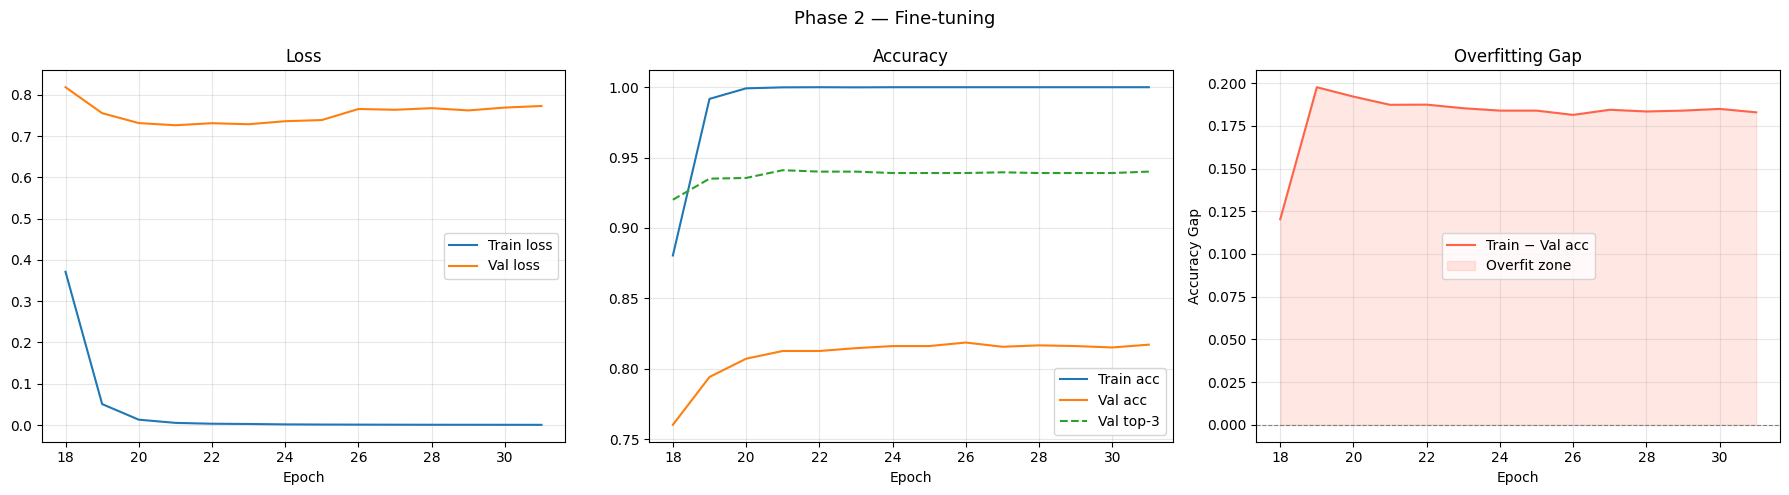

In [ ]:
plot_history(history2, title='Phase 2 — Fine-tuning',
             offset=len(history1.history['accuracy']))

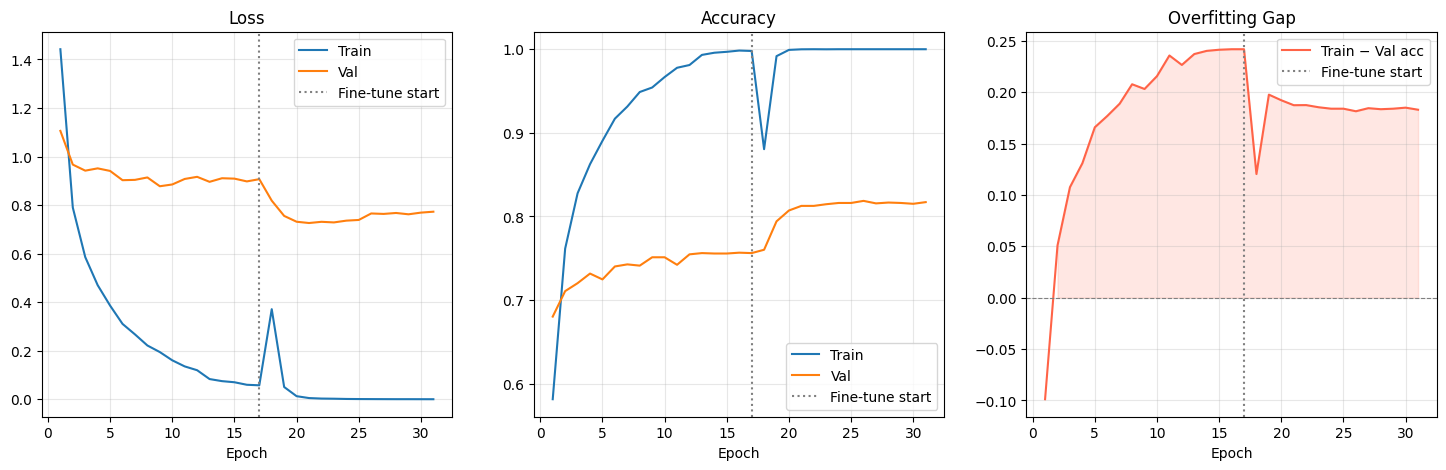

In [ ]:
# Combined training curve (Phase 1 + Phase 2)
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

combined = combine_histories(history1, history2)
phase1_end = len(history1.history['accuracy'])
total_epochs = len(combined['accuracy'])
epochs_range = range(1, total_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, key, val_key, title in [
    (axes[0], 'loss',     'val_loss',     'Loss'),
    (axes[1], 'accuracy', 'val_accuracy', 'Accuracy'),
]:
    ax.plot(epochs_range, combined[key],     label='Train')
    ax.plot(epochs_range, combined[val_key], label='Val')
    ax.axvline(phase1_end, color='gray', linestyle=':', label='Fine-tune start')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)

# Gap subplot
gap = [tr - va for tr, va in zip(combined['accuracy'], combined['val_accuracy'])]
axes[2].plot(epochs_range, gap, color='tomato', label='Train − Val acc')
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].fill_between(epochs_range, gap, 0,
                      where=[g > 0 for g in gap],
                      alpha=0.15, color='tomato')
axes[2].axvline(phase1_end, color='gray', linestyle=':', label='Fine-tune start')
axes[2].set_title('Overfitting Gap'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(alpha=0.3)

---
## 5. Evaluation on Test Set

In [ ]:
# Load best fine-tuned weights for final evaluation
model.load_weights('best_final.weights.h5')

test_loss, test_acc, test_top3 = model.evaluate(test_ds, verbose=1)
print(f'\nTest  Loss     : {test_loss:.4f}')
print(f'Test  Top-1 Acc: {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Test  Top-3 Acc: {test_top3:.4f}  ({test_top3*100:.2f}%)')

### Test-Time Augmentation (TTA)

In [ ]:
TTA_STEPS = 10

tta_aug = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomBrightness(factor=0.08),
], name='tta_aug')

def apply_tta(img, label):
    img = tta_aug(img, training=True)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = keras.applications.efficientnet.preprocess_input(img)
    return img, label

y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds_raw])
n_test = len(y_true)

print(f'Running TTA with {TTA_STEPS} passes...')
tta_probs = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)
for step in range(TTA_STEPS):
    tta_ds = test_ds_raw.map(apply_tta, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    tta_probs += model.predict(tta_ds, verbose=0)
    print(f'  Step {step + 1}/{TTA_STEPS}')
tta_probs /= TTA_STEPS

y_pred_standard = np.argmax(model.predict(test_ds, verbose=0), axis=1)
y_pred_tta      = np.argmax(tta_probs, axis=1)

acc_std = (y_pred_standard == y_true).mean()
acc_tta = (y_pred_tta      == y_true).mean()
print(f'Standard accuracy : {acc_std:.4f} ({acc_std * 100:.2f}%)')
print(f'TTA accuracy      : {acc_tta:.4f} ({acc_tta * 100:.2f}%)')
print(f'TTA improvement   : {(acc_tta - acc_std) * 100:+.2f}%')

y_pred_probs = tta_probs
y_pred       = y_pred_tta

### Classification Report & Confusion Matrix

In [ ]:
# Per-class classification report
artist_names_short = [n.replace('_', ' ') for n in class_names]
report = classification_report(y_true, y_pred, target_names=artist_names_short, digits=3)
print('Classification Report')
print('=' * 60)
print(report)

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=artist_names_short,
    yticklabels=artist_names_short,
    linewidths=0.3, ax=ax
)
ax.set_xlabel('Predicted Artist', fontsize=12)
ax.set_ylabel('True Artist', fontsize=12)
ax.set_title('Normalised Confusion Matrix (row = true class)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Per-class F1 bar chart
f1_per_class = f1_score(y_true, y_pred, average=None)

order = np.argsort(f1_per_class)
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#d73027' if f < 0.5 else '#4575b4' for f in f1_per_class[order]]
bars = ax.barh([artist_names_short[i] for i in order], f1_per_class[order], color=colors)
ax.axvline(np.mean(f1_per_class), color='black', linestyle='--',
           label=f'Macro F1: {np.mean(f1_per_class):.3f}')
ax.set_xlabel('F1 Score')
ax.set_title('Per-class F1 Score on Test Set')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
print(f'Macro F1    : {macro_f1:.4f}')
print(f'Weighted F1 : {weighted_f1:.4f}')

### Error Analysis — Misclassified Examples

In [ ]:
# Show misclassified images with true vs predicted labels
test_file_paths = np.array(test_ds_raw.file_paths)

wrong_mask  = y_pred != y_true
wrong_paths = test_file_paths[wrong_mask]
wrong_true  = y_true[wrong_mask]
wrong_pred  = y_pred[wrong_mask]
wrong_conf  = y_pred_probs[wrong_mask].max(axis=1)

# Pick 12 high-confidence mistakes
high_conf_idx = np.argsort(wrong_conf)[::-1][:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, idx in zip(axes.flatten(), high_conf_idx):
    img = mpimg.imread(wrong_paths[idx])
    true_name = class_names[wrong_true[idx]].replace('_', ' ')
    pred_name = class_names[wrong_pred[idx]].replace('_', ' ')
    conf      = wrong_conf[idx]
    ax.imshow(img)
    ax.set_title(f'True: {true_name} Pred: {pred_name} ({conf:.2f})',
                 fontsize=7, color='red')
    ax.axis('off')

plt.suptitle('High-Confidence Misclassifications', fontsize=13)
plt.tight_layout()
plt.show()

### Grad-CAM — Where Does the Model Look?

In [ ]:
def make_gradcam_heatmap(img_array, model, pred_index=None):
    """Generate a Grad-CAM heatmap for the given image."""
    backbone = model.get_layer(base_model.name)
    last_conv_name = None
    for layer in reversed(backbone.layers):
        if isinstance(layer, keras.layers.Conv2D):
            last_conv_name = layer.name
            break

    grad_model = keras.Model(
        inputs=model.input,
        outputs=[
            backbone.get_layer(last_conv_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(tf.argmax(predictions[0]))


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on the original image."""
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    colormap        = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    colormap        = cv2.cvtColor(colormap, cv2.COLOR_BGR2RGB)

    superimposed = np.uint8(alpha * colormap + (1 - alpha) * img)
    return img, superimposed


def preprocess_single_image(img_path):
    """Load and preprocess a single image for the model."""
    img = keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    return img_array


# Generate Grad-CAM visualisations — 2 correctly classified per artist
N_PER_ARTIST = 2
correct_mask = y_pred == y_true

artist_examples = {cls: [] for cls in range(NUM_CLASSES)}
for i in range(len(y_true)):
    if correct_mask[i] and len(artist_examples[y_true[i]]) < N_PER_ARTIST:
        artist_examples[y_true[i]].append(test_file_paths[i])

n_artists = len(class_names)
fig, axes = plt.subplots(n_artists, 3 * N_PER_ARTIST,
                         figsize=(5 * N_PER_ARTIST * 3, n_artists * 2.5))

for row, cls_idx in enumerate(range(n_artists)):
    for ex_i, img_path in enumerate(artist_examples[cls_idx]):
        img_tensor = preprocess_single_image(img_path)
        heatmap, pred_cls = make_gradcam_heatmap(img_tensor, model)
        original, overlay = overlay_gradcam(img_path, heatmap)

        col_base = ex_i * 3

        axes[row, col_base].imshow(original)
        if row == 0:
            axes[row, col_base].set_title('Original', fontsize=8)
        axes[row, col_base].axis('off')

        hm_resized = cv2.resize(heatmap, IMG_SIZE)
        axes[row, col_base + 1].imshow(hm_resized, cmap='jet')
        if row == 0:
            axes[row, col_base + 1].set_title('Grad-CAM', fontsize=8)
        axes[row, col_base + 1].axis('off')

        axes[row, col_base + 2].imshow(overlay)
        if row == 0:
            axes[row, col_base + 2].set_title('Overlay', fontsize=8)
        axes[row, col_base + 2].axis('off')

    axes[row, 0].set_ylabel(class_names[cls_idx].replace('_', '\n'),
                            fontsize=7, rotation=0, labelpad=60, va='center')

plt.suptitle('Grad-CAM Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Attention distribution analysis — border vs center
print('\n-- Attention Distribution Analysis --')
print('Checking if activation is concentrated in borders (possible signature)\n')

border_ratios = {cls: [] for cls in class_names}

for cls_idx in range(n_artists):
    for img_path in artist_examples[cls_idx]:
        img_tensor = preprocess_single_image(img_path)
        heatmap, _ = make_gradcam_heatmap(img_tensor, model)
        hm = cv2.resize(heatmap, IMG_SIZE)

        h, w = hm.shape
        margin_h, margin_w = int(h * 0.15), int(w * 0.15)

        border_mask = np.zeros_like(hm, dtype=bool)
        border_mask[:margin_h, :] = True
        border_mask[-margin_h:, :] = True
        border_mask[:, :margin_w] = True
        border_mask[:, -margin_w:] = True

        total_activation = hm.sum()
        if total_activation > 0:
            border_ratio = hm[border_mask].sum() / total_activation
        else:
            border_ratio = 0.0
        border_ratios[class_names[cls_idx]].append(border_ratio)

print(f'{"Artist":<30} {"Border %":>10} {"Center %":>10}  Interpretation')
print('-' * 75)
for cls in class_names:
    mean_border = np.mean(border_ratios[cls]) * 100
    mean_center = 100 - mean_border
    flag = 'possible signature bias' if mean_border > 55 else 'style-focused'
    print(f'{cls.replace("_", " "):<30} {mean_border:>9.1f}% {mean_center:>9.1f}%  {flag}')

---
## 6. Final Summary

In [ ]:
n_train = len(train_ds_raw.file_paths)
n_val   = sum(len(list(d.iterdir())) for d in val_dir.iterdir())

print('=' * 50)
print('        FINAL RESULTS SUMMARY')
print('=' * 50)
print(f'  Test Top-1 Accuracy : {test_acc*100:.2f}%')
print(f'  Test Top-3 Accuracy : {test_top3*100:.2f}%')
print(f'  Macro F1            : {macro_f1:.4f}')
print(f'  Weighted F1         : {weighted_f1:.4f}')
print(f'  Test Loss           : {test_loss:.4f}')
print('=' * 50)
print(f'  Architecture        : EfficientNetB0 + custom head')
print(f'  Total parameters    : {total_params:,}')
print(f'  Classes             : {NUM_CLASSES}')
print(f'  Train / Val / Test  : {n_train} / {n_val} / {n_test}')
print('=' * 50)

---
## 7. Save Weights to Google Drive

In [ ]:
import shutil

save_dir = Path('/content/drive/MyDrive/wikiart_weights')
save_dir.mkdir(parents=True, exist_ok=True)

for f in ['best_phase1.weights.h5', 'best_final.weights.h5']:
    if Path(f).exists():
        shutil.copy2(f, save_dir / f)
        print(f'Saved {f} -> {save_dir / f}')

print('Done!')